# 7B Block-Design Analysis

**Data:** each run consists of 20 emotional prompts followed by 20 neutral prompts (or vice versa), separated by a full node reboot.

**Pipeline:**
1. Clustering on **raw** features — single-feature sweep, majority filter, MWU with Bonferroni.
2. Check if `elapsed_ms` differs significantly between conditions. Residualise only if it does.
3. Clustering on **residualised** features (if applicable).
4. **Null test:** random label assignment within a single condition, checked across 20 repeats. Accuracy should hover around 50%.

**Note on residualisation:** `prompt_index` is NOT used as a covariate — in the block design, emotional and neutral trials occupy different block positions, so prompt_index is fully correlated with condition label and cannot serve as a confound control.

## §1 — Imports and configuration

In [11]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
DATA_DIR   = BASE_DIR / 'data' / 'longer70b'
RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
RUNS = ['219a', '219b', '219c', '220a', '233a', '233c']

# ── L1 indicators ─────────────────────────────────────────────────────────────
L1_INDICATORS = [
    #'hat_TLB',
    #'tlb:tlb_flush',
    'core_power.throttle',
]
# ── Analysis config ────────────────────────────────────────────────────────────
MAJORITY_THRESHOLD = 0.75
N_INIT             = 50
RAND_SEED          = 42
N_NULL_REPEATS     = 20

print('Configuration OK')
print(f'  Runs              : {RUNS}')
print(f'  Majority threshold: {MAJORITY_THRESHOLD:.0%}')
print(f'  Null repeats      : {N_NULL_REPEATS}')


Configuration OK
  Runs              : ['219a', '219b', '219c', '220a', '233a', '233c']
  Majority threshold: 75%
  Null repeats      : 20


## §2 — Load data

In [12]:
dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'blocks{run}', run]:
        p = DATA_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

assert dfs, 'No data loaded. Check DATA_DIR and RUNS.'
df_all = pd.concat(dfs, ignore_index=True)
df_all['label'] = (df_all['condition'] == 'emotional').astype(int)

print(f'Loaded {len(runs_loaded)} runs: {runs_loaded}')
print(f'  Total trials : {len(df_all)}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')

Loaded 6 runs: ['219a', '219b', '219c', '220a', '233a', '233c']
  Total trials : 240
  Emotional    : 120
  Neutral      : 120


## §3 — Select L1 features

In [13]:
def indicator_of(col):
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

l1_cols = [c for c in df_all.columns if indicator_of(c) in L1_INDICATORS]

X_l1 = df_all[l1_cols].copy()
X_l1 = X_l1.dropna(axis=1, how='all')
X_l1 = X_l1.fillna(X_l1.median())
X_l1 = X_l1.loc[:, X_l1.std() > 0]

print(f'L1 features available: {X_l1.shape[1]}')
print(f'Features: {list(X_l1.columns)}')

L1 features available: 10
Features: ['core_power.throttle__mean_rate', 'core_power.throttle__variance', 'core_power.throttle__p90_p10', 'core_power.throttle__slope', 'core_power.throttle__spectral_entropy', 'core_power.throttle__iat_cv', 'core_power.throttle__burst_rate', 'core_power.throttle__burst_clustering', 'core_power.throttle__lz_complexity', 'core_power.throttle__perm_entropy']


## §4 — Helper functions

In [14]:
def kmeans_acc_ari(X, y, n_init=N_INIT, seed=RAND_SEED):
    """K-means (k=2) with majority-vote alignment. Returns (accuracy, ARI)."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed)
    pred = km.fit_predict(Xs)
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


def single_feature_sweep(X_feat_df, df, label_col='label'):
    """Single-feature sweep with per-run direction analysis and majority filter."""
    y_true = df[label_col].values
    runs_unique = df['run'].unique()
    records = []
    for col in X_feat_df.columns:
        acc, ari = kmeans_acc_ari(X_feat_df[[col]].values, y_true)
        e_mean = X_feat_df.loc[df['condition'] == 'emotional', col].mean()
        n_mean = X_feat_df.loc[df['condition'] == 'neutral',   col].mean()
        direction = '↑E' if e_mean > n_mean else '↑N'
        
        run_dirs = []
        for run in runs_unique:
            mask_run = df['run'] == run
            e_run = X_feat_df.loc[mask_run & (df['condition'] == 'emotional'), col].mean()
            n_run = X_feat_df.loc[mask_run & (df['condition'] == 'neutral'),   col].mean()
            if not (np.isnan(e_run) or np.isnan(n_run)):
                run_dirs.append('↑E' if e_run > n_run else '↑N')
        
        n_majority = sum(1 for d in run_dirs if d == direction)
        n_valid    = len(run_dirs)
        maj_frac   = n_majority / n_valid if n_valid > 0 else 0.0
        
        records.append({
            'feature':       col,
            'accuracy':      acc,
            'ari':           ari,
            'direction':     direction,
            'runs_majority': f'{n_majority}/{n_valid}',
            'majority_frac': maj_frac,
        })
    return pd.DataFrame(records).sort_values('accuracy', ascending=False).reset_index(drop=True)


def mwu_bonferroni(X_feat_df, df, features):
    """Mann-Whitney U with Bonferroni correction for a list of features."""
    if not len(features):
        return pd.DataFrame()
    records = []
    for feat in features:
        e = X_feat_df.loc[df.condition == 'emotional', feat].dropna()
        n = X_feat_df.loc[df.condition == 'neutral',   feat].dropna()
        u, p_raw = mannwhitneyu(e, n, alternative='two-sided')
        p_corr = min(p_raw * len(features), 1.0)
        records.append({
            'feature':     feat,
            'U':           u,
            'p_raw':       p_raw,
            'p_corrected': p_corr,
            'significant': 'YES' if p_corr < 0.05 else 'NO',
        })
    return pd.DataFrame(records)

print('Helpers defined.')

Helpers defined.


## §5 — Raw clustering (no residualisation)

In [15]:
print('=' * 70)
print('RAW CLUSTERING (no residualisation)')
print('=' * 70)

sf_raw = single_feature_sweep(X_l1, df_all)

print('\nAll features (sorted by accuracy):')
print(sf_raw[['feature', 'accuracy', 'ari', 'direction', 'runs_majority', 'majority_frac']].to_string(index=False))

sf_raw_filtered = sf_raw[sf_raw['majority_frac'] >= MAJORITY_THRESHOLD].reset_index(drop=True)
print(f'\nFeatures passing ≥{MAJORITY_THRESHOLD:.0%} majority: {len(sf_raw_filtered)}')
if len(sf_raw_filtered):
    print(sf_raw_filtered[['feature', 'accuracy', 'ari', 'direction', 'runs_majority']].to_string(index=False))

print('\nMann-Whitney U (Bonferroni-corrected across majority-passing features):')
mwu_raw = mwu_bonferroni(X_l1, df_all, sf_raw_filtered['feature'].tolist())
if not mwu_raw.empty:
    print(mwu_raw.to_string(index=False))
else:
    print('  No features passed majority threshold.')

RAW CLUSTERING (no residualisation)

All features (sorted by accuracy):
                              feature  accuracy       ari direction runs_majority  majority_frac
         core_power.throttle__p90_p10  0.637500  0.071819        ↑N           6/6       1.000000
core_power.throttle__spectral_entropy  0.633333  0.067296        ↑E           6/6       1.000000
           core_power.throttle__slope  0.629167  0.063766        ↑N           6/6       1.000000
   core_power.throttle__lz_complexity  0.604167  0.041906        ↑E           6/6       1.000000
        core_power.throttle__variance  0.583333  0.023703        ↑N           6/6       1.000000
       core_power.throttle__mean_rate  0.575000  0.021364        ↑N           2/6       0.333333
          core_power.throttle__iat_cv  0.570833  0.018758        ↑E           1/6       0.166667
    core_power.throttle__perm_entropy  0.541667  0.004116        ↑N           3/6       0.500000
core_power.throttle__burst_clustering  0.529167 -0.0006

## §6 — Check elapsed_ms for condition bias

In [16]:
print('elapsed_ms by condition:')
for cond in ['emotional', 'neutral']:
    v = df_all.loc[df_all.condition == cond, 'elapsed_ms'].dropna()
    print(f'  {cond:10s}  n={len(v):4d}  mean={v.mean():.0f}  median={v.median():.0f}  std={v.std():.0f}')

e = df_all[df_all.condition == 'emotional']['elapsed_ms'].dropna()
n = df_all[df_all.condition == 'neutral']['elapsed_ms'].dropna()
u, p_ms = mannwhitneyu(e, n, alternative='two-sided')
print(f'\nMann-Whitney U: U={u:.1f}  p={p_ms:.4f}')

RESIDUALISE = p_ms >= 0.05
print(f'\nDecision: {"RESIDUALISE against elapsed_ms" if RESIDUALISE else "DO NOT residualise — elapsed_ms is a potential mediator"}')

elapsed_ms by condition:
  emotional   n= 120  mean=62156  median=61605  std=3049
  neutral     n= 120  mean=62152  median=62198  std=1849

Mann-Whitney U: U=6466.0  p=0.1726

Decision: RESIDUALISE against elapsed_ms


## §7 — Residualised clustering (elapsed_ms only, if applicable)

In [17]:
if RESIDUALISE:
    cov_ms = df_all['elapsed_ms'].values.astype(float)
    cov_ms_c = cov_ms - cov_ms.mean()
    A = np.column_stack([np.ones(len(df_all)), cov_ms_c])
    
    X_l1_resid = X_l1.copy()
    for col in X_l1.columns:
        y_col = X_l1[col].values.astype(float)
        coefs, _, _, _ = np.linalg.lstsq(A, y_col, rcond=None)
        X_l1_resid[col] = y_col - A @ coefs
    
    print('=' * 70)
    print('RESIDUALISED CLUSTERING (elapsed_ms only)')
    print('=' * 70)
    
    sf_resid = single_feature_sweep(X_l1_resid, df_all)
    print('\nAll features (sorted by accuracy):')
    print(sf_resid[['feature', 'accuracy', 'ari', 'direction', 'runs_majority', 'majority_frac']].to_string(index=False))
    
    sf_resid_filtered = sf_resid[sf_resid['majority_frac'] >= MAJORITY_THRESHOLD].reset_index(drop=True)
    print(f'\nFeatures passing ≥{MAJORITY_THRESHOLD:.0%} majority: {len(sf_resid_filtered)}')
    if len(sf_resid_filtered):
        print(sf_resid_filtered[['feature', 'accuracy', 'ari', 'direction', 'runs_majority']].to_string(index=False))
    
    print('\nMann-Whitney U (Bonferroni-corrected):')
    mwu_resid = mwu_bonferroni(X_l1_resid, df_all, sf_resid_filtered['feature'].tolist())
    if not mwu_resid.empty:
        print(mwu_resid.to_string(index=False))
    else:
        print('  No features passed majority threshold.')
else:
    print('Skipped: elapsed_ms differs significantly between conditions and is a potential mediator.')
    print('Raw clustering results are used as the final results.')

RESIDUALISED CLUSTERING (elapsed_ms only)

All features (sorted by accuracy):
                              feature  accuracy      ari direction runs_majority  majority_frac
core_power.throttle__spectral_entropy  0.670833 0.113027        ↑E           6/6       1.000000
           core_power.throttle__slope  0.650000 0.086385        ↑N           6/6       1.000000
         core_power.throttle__p90_p10  0.645833 0.081286        ↑N           6/6       1.000000
   core_power.throttle__lz_complexity  0.645833 0.081393        ↑E           6/6       1.000000
        core_power.throttle__variance  0.612500 0.046670        ↑N           6/6       1.000000
       core_power.throttle__mean_rate  0.600000 0.036726        ↑N           6/6       1.000000
          core_power.throttle__iat_cv  0.554167 0.007649        ↑E           3/6       0.500000
core_power.throttle__burst_clustering  0.541667 0.002829        ↑E           4/6       0.666667
    core_power.throttle__perm_entropy  0.529167 0.000685  

## §8 — Null test: random labels within a single condition

Clustering on emotional-only trials (or neutral-only trials) with randomly assigned pseudo-labels. Accuracy should hover around 50% and ARI around 0, confirming there is no spurious structure being picked up.

In [18]:
# Pick the best raw feature to test for spurious structure
NULL_FEATURE = sf_raw.iloc[0]['feature']
print(f'Null test feature: {NULL_FEATURE}')
print(f'(Testing whether clustering picks up structure with random labels)\n')

rng = np.random.default_rng(RAND_SEED)

for cond in ['emotional', 'neutral']:
    sub = df_all[df_all.condition == cond].copy().reset_index(drop=True)
    n_total = len(sub)
    X_sub = sub[[NULL_FEATURE]].fillna(sub[[NULL_FEATURE]].median()).values
    
    accs, aris = [], []
    for _ in range(N_NULL_REPEATS):
        # Assign exactly 50/50 random pseudo-labels
        pseudo = np.zeros(n_total, dtype=int)
        pseudo[:n_total // 2] = 1
        rng.shuffle(pseudo)
        
        if len(np.unique(pseudo)) < 2:
            continue
        
        acc, ari = kmeans_acc_ari(X_sub, pseudo)
        accs.append(acc)
        aris.append(ari)
    
    print(f'{cond:10s}  n={n_total:4d}  '
          f'mean_acc={np.mean(accs):.4f} ± {np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f} ± {np.std(aris):.4f}')

print(f'\nExpected: accuracy ≈ 0.50, ARI ≈ 0.00')
print(f'Repeats per condition: {N_NULL_REPEATS}')

Null test feature: core_power.throttle__p90_p10
(Testing whether clustering picks up structure with random labels)

emotional   n= 120  mean_acc=0.5283 ± 0.0248  mean_ARI=-0.0028 ± 0.0095
neutral     n= 120  mean_acc=0.5350 ± 0.0268  mean_ARI=-0.0006 ± 0.0104

Expected: accuracy ≈ 0.50, ARI ≈ 0.00
Repeats per condition: 20


## §9 — Summary

In [19]:
print('=' * 70)
print('SUMMARY')
print('=' * 70)
print(f'Runs loaded          : {len(runs_loaded)}')
print(f'Total trials         : {len(df_all)}')
print(f'Features tested      : {X_l1.shape[1]}')
print()
print(f'Raw clustering — best feature      : {sf_raw.iloc[0].feature}')
print(f'                  accuracy         : {sf_raw.iloc[0].accuracy:.4f}')
print(f'                  ARI              : {sf_raw.iloc[0].ari:.4f}')
print(f'                  direction        : {sf_raw.iloc[0].direction} ({sf_raw.iloc[0].runs_majority})')
print()
print(f'elapsed_ms condition difference: p={p_ms:.4f}')
print(f'Residualisation applied        : {RESIDUALISE}')
if RESIDUALISE:
    print(f'Residualised — best feature    : {sf_resid.iloc[0].feature}')
    print(f'                  accuracy     : {sf_resid.iloc[0].accuracy:.4f}')
    print(f'                  ARI          : {sf_resid.iloc[0].ari:.4f}')
    print(f'                  direction    : {sf_resid.iloc[0].direction} ({sf_resid.iloc[0].runs_majority})')

SUMMARY
Runs loaded          : 6
Total trials         : 240
Features tested      : 10

Raw clustering — best feature      : core_power.throttle__p90_p10
                  accuracy         : 0.6375
                  ARI              : 0.0718
                  direction        : ↑N (6/6)

elapsed_ms condition difference: p=0.1726
Residualisation applied        : True
Residualised — best feature    : core_power.throttle__spectral_entropy
                  accuracy     : 0.6708
                  ARI          : 0.1130
                  direction    : ↑E (6/6)


# ROB SWEEP

In [21]:
# ── Robustness sweep on the best raw feature ──────────────────────────────────
# For each subset size x, draw x/2 emotional + x/2 neutral prompt_indices,
# pool across all runs, and run clustering. Repeat N_REPEATS times.

SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
N_REPEATS    = 20

BEST_FEATURE = sf_resid.iloc[0]['feature']
print(f'Robustness sweep feature: {BEST_FEATURE}\n')

emotional_prompts = sorted(df_all[df_all.condition == 'emotional']['prompt_index'].unique())
neutral_prompts   = sorted(df_all[df_all.condition == 'neutral']['prompt_index'].unique())

print(f'Emotional prompt indices ({len(emotional_prompts)}): {emotional_prompts}')
print(f'Neutral prompt indices   ({len(neutral_prompts)}):   {neutral_prompts}')
print()

rng = np.random.default_rng(RAND_SEED)
results = []

for x in SUBSET_SIZES:
    half = x // 2
    assert half <= min(len(emotional_prompts), len(neutral_prompts)), \
        f'x/2={half} exceeds available prompts per condition'

    accs, aris = [], []
    for _ in range(N_REPEATS):
        e_sel = rng.choice(emotional_prompts, size=half, replace=False)
        n_sel = rng.choice(neutral_prompts,   size=half, replace=False)

        mask = (
            ((df_all.condition == 'emotional') & (df_all.prompt_index.isin(e_sel))) |
            ((df_all.condition == 'neutral')   & (df_all.prompt_index.isin(n_sel)))
        )
        X_sub = X_l1_resid.loc[mask, BEST_FEATURE].values.reshape(-1, 1)
        y_sub = df_all.loc[mask, 'label'].values

        if len(np.unique(y_sub)) < 2:
            continue

        acc, ari = kmeans_acc_ari(X_sub, y_sub)
        accs.append(acc)
        aris.append(ari)

    results.append({
        'x':        x,
        'total':    x * len(runs_loaded),
        'mean_acc': np.mean(accs),
        'std_acc':  np.std(accs),
        'mean_ari': np.mean(aris),
        'std_ari':  np.std(aris),
    })
    print(f'  x={x:2d}  total={x*len(runs_loaded):4d}  '
          f'mean_acc={np.mean(accs):.4f}  ±{np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f}')

res = pd.DataFrame(results)

Robustness sweep feature: core_power.throttle__spectral_entropy

Emotional prompt indices (20): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Neutral prompt indices   (20):   [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

  x=22  total= 132  mean_acc=0.6568  ±0.0301  mean_ARI=0.0951
  x=24  total= 144  mean_acc=0.6524  ±0.0284  mean_ARI=0.0899
  x=26  total= 156  mean_acc=0.6692  ±0.0347  mean_ARI=0.1137
  x=28  total= 168  mean_acc=0.6690  ±0.0237  mean_ARI=0.1113
  x=30  total= 180  mean_acc=0.6714  ±0.0225  mean_ARI=0.1146
  x=32  total= 192

<function matplotlib.pyplot.show(close=None, block=None)>

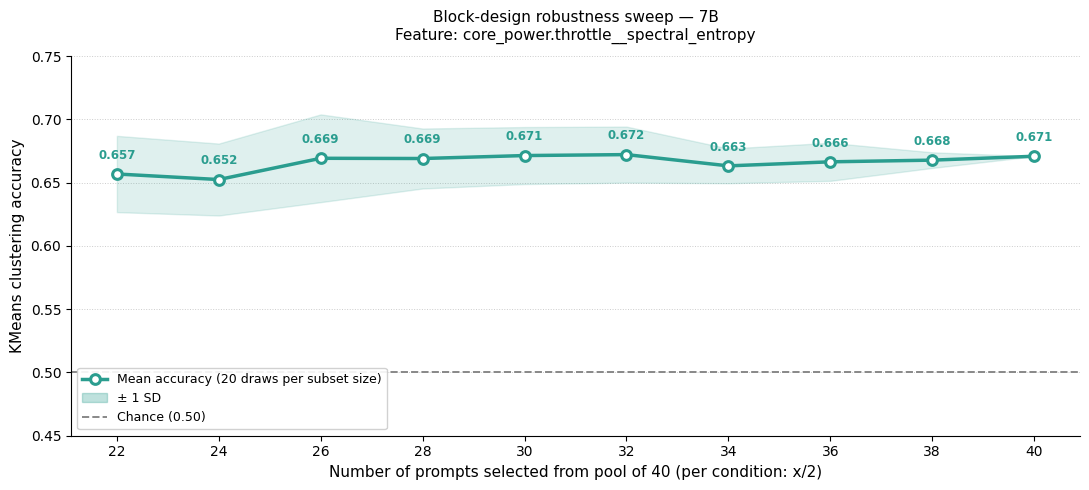

In [22]:
COLOR      = '#2a9d8f'
COLOR_BAND = '#2a9d8f'

xs   = res['x'].values
mean = res['mean_acc'].values
std  = res['std_acc'].values

fig, ax = plt.subplots(figsize=(11, 5))

# Shaded band first
ax.fill_between(xs, mean - std, mean + std,
                alpha=0.15, color=COLOR_BAND, zorder=1)

# Main line
ax.plot(xs, mean, marker='o', lw=2.5, color=COLOR,
        markersize=7, markerfacecolor='white', markeredgewidth=2.2,
        zorder=3, label='Mean accuracy (20 draws per subset size)')

# SD band label for legend
import matplotlib.patches as mpatches
band_patch = mpatches.Patch(color=COLOR_BAND, alpha=0.3, label='± 1 SD')

# Chance line
ax.axhline(0.5, color='#888888', lw=1.4, ls='--', zorder=2, label='Chance (0.50)')

# Accuracy labels above points
for xi, mi in zip(xs, mean):
    ax.annotate(f'{mi:.3f}', xy=(xi, mi),
                textcoords='offset points', xytext=(0, 11),
                ha='center', fontsize=8.5, color=COLOR, fontweight='bold')

# Axes
ax.set_xlabel('Number of prompts selected from pool of 40 (per condition: x/2)', fontsize=11)
ax.set_ylabel('KMeans clustering accuracy', fontsize=11)
ax.set_xticks(xs)
ax.set_xticklabels([str(xi) for xi in xs], fontsize=10)
ax.set_ylim(0.45, 0.75)
ax.tick_params(axis='y', labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

# Grid
ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='#cccccc', zorder=0)
ax.set_axisbelow(True)

# Title
ax.set_title(
    f'Block-design robustness sweep — 7B\n'
    f'Feature: {BEST_FEATURE}',
    fontsize=11, pad=12
)

ax.legend(handles=[ax.lines[0], band_patch, ax.lines[1]],
          fontsize=9, framealpha=0.9, loc='lower left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show